# Seasonal Agriculture Performance Analysis

### Major Data Analytics Project
**Domain:** Agriculture
**Project Theme:** Seasonal Agriculture Performance
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

### Project Goal
Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.



### 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and economic conditions. As a result, agricultural performance may differ from one season to another.

The objective of this project is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

Students should independently explore the dataset, formulate relevant analytical questions, select suitable analytical techniques and communicate findings based on evidence from the data.

### 2. Project Objectives

* Understand the structure and quality of the agricultural dataset.
* Clean and prepare the data for analysis.
* Explore seasonal patterns in the dataset.
* Perform descriptive and statistical analysis.
* Investigate relationships among relevant variables.
* Compare agricultural performance across seasons and other meaningful groups.
* Use appropriate univariate, bivariate and multivariate visualizations.
* Identify significant findings from the data.
* Develop evidence-based insights and recommendations.

### 3. Dataset

The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

**Dataset file:** `seasonal_agriculture_performance_dataset.csv`

The notebook is designed so that students can upload/place the CSV in the same folder as this notebook.

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [ ]:
# Load the dataset
file_path = "/content/seasonal_agriculture_performance_dataset.xlsx"
df = pd.read_excel(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


### 4. Initial Data Understanding

In [ ]:
# Dataset shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


In [ ]:
# Top 5 rows
df.head(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [ ]:
# Bottom 5 rows
df.tail(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [ ]:
# Random sample of records
df.sample(5, random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,"1,213.70",26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


### 5. Data Cleaning and Preprocessing
Checking for missing values and data types to ensure high data quality before analysis.

In [ ]:
# Check for missing values and data types
print(df.info())
print("\nMissing Values Count:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
# Handle missing values by imputing with median for numerical columns
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].median())
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df['Soil_Moisture_pct'].median())
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(df['Yield_Tonnes_Ha'].median())

print("Missing values resolved:\n", df.isnull().sum().sum(), "total missing values remain.")

Missing values resolved:
 0 total missing values remain.


### 6. Exploratory Data Analysis (EDA) - Visualizations
Analyzing the seasonal variations using individual graphs for professional clarity.

In [ ]:
# Summary statistics table grouped by Season
seasonal_summary = df.groupby('Season')[['Rainfall_mm', 'Water_Used_m3', 'Total_Cost_INR', 'Profit_INR', 'Yield_Tonnes_Ha']].mean()
display(seasonal_summary)

,Rainfall_mm,Water_Used_m3,Total_Cost_INR,Profit_INR,Yield_Tonnes_Ha
Season,,,,,
Kharif,849.20,"6,102.20","531,804.41","178,914.65",5.63
Rabi,437.62,"5,846.99","513,836.58","87,689.47",5.04
Zaid,304.65,"6,419.89","543,976.73","-24,804.82",4.64


/tmp/ipykernel_1262/153774366.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Season', data=df, palette='viridis')


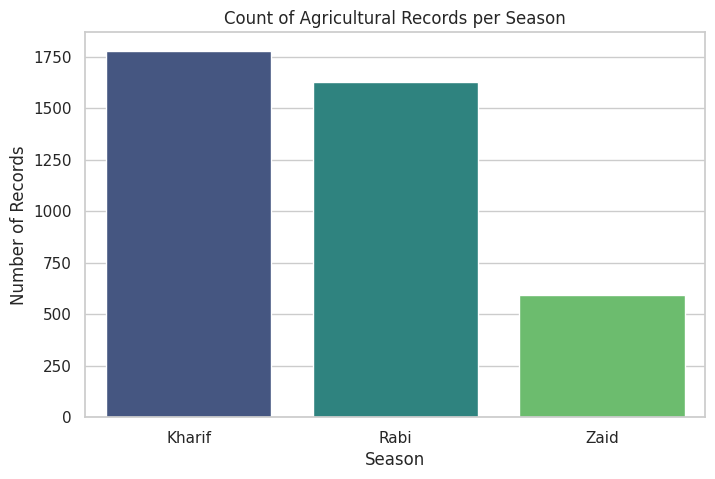

In [ ]:
# Graph 1: Distribution of Seasons in the Dataset
plt.figure(figsize=(8, 5))
sns.countplot(x='Season', data=df, palette='viridis')
plt.title('Count of Agricultural Records per Season')
plt.ylabel('Number of Records')
plt.show()

/tmp/ipykernel_1262/3728776588.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Season', y='Rainfall_mm', data=df, palette='Blues', ci=None)
/tmp/ipykernel_1262/3728776588.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Season', y='Rainfall_mm', data=df, palette='Blues', ci=None)


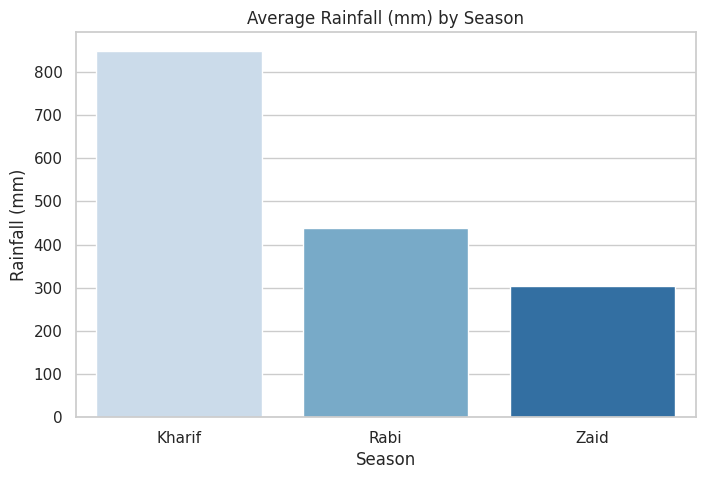

In [ ]:
# Graph 2: Average Rainfall Across Seasons
plt.figure(figsize=(8, 5))
sns.barplot(x='Season', y='Rainfall_mm', data=df, palette='Blues', ci=None)
plt.title('Average Rainfall (mm) by Season')
plt.ylabel('Rainfall (mm)')
plt.show()

/tmp/ipykernel_1262/1272148081.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Season', y='Yield_Tonnes_Ha', data=df, palette='Greens', ci=None)
/tmp/ipykernel_1262/1272148081.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Season', y='Yield_Tonnes_Ha', data=df, palette='Greens', ci=None)


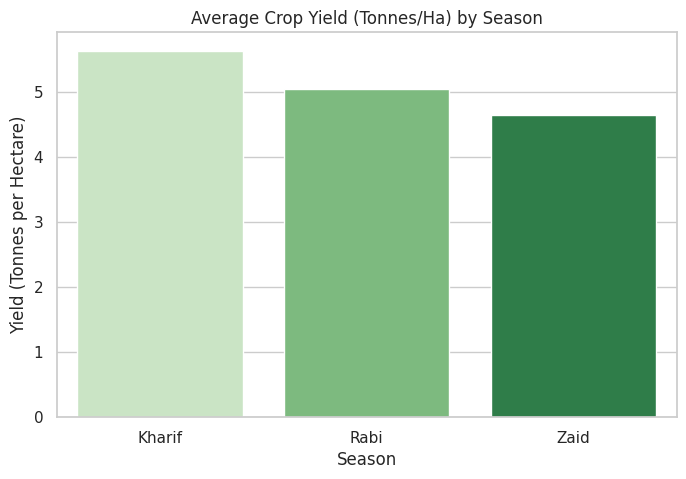

In [ ]:
# Graph 3: Average Yield Across Seasons
plt.figure(figsize=(8, 5))
sns.barplot(x='Season', y='Yield_Tonnes_Ha', data=df, palette='Greens', ci=None)
plt.title('Average Crop Yield (Tonnes/Ha) by Season')
plt.ylabel('Yield (Tonnes per Hectare)')
plt.show()

/tmp/ipykernel_1262/1415771745.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Season', y='Profit_INR', data=df, palette='magma', ci=None)
/tmp/ipykernel_1262/1415771745.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Season', y='Profit_INR', data=df, palette='magma', ci=None)


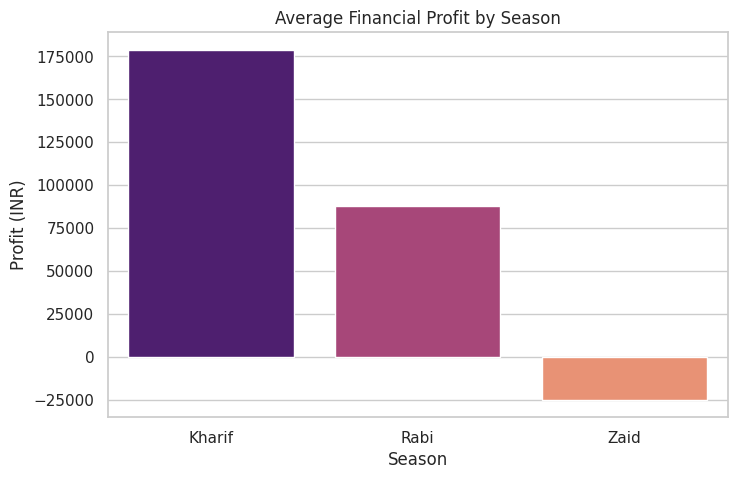

In [ ]:
# Graph 4: Profitability Across Seasons
plt.figure(figsize=(8, 5))
sns.barplot(x='Season', y='Profit_INR', data=df, palette='magma', ci=None)
plt.title('Average Financial Profit by Season')
plt.ylabel('Profit (INR)')
plt.show()

/tmp/ipykernel_1262/986432328.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Season', y='Water_Used_m3', data=df, palette='coolwarm', ci=None)
/tmp/ipykernel_1262/986432328.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Season', y='Water_Used_m3', data=df, palette='coolwarm', ci=None)


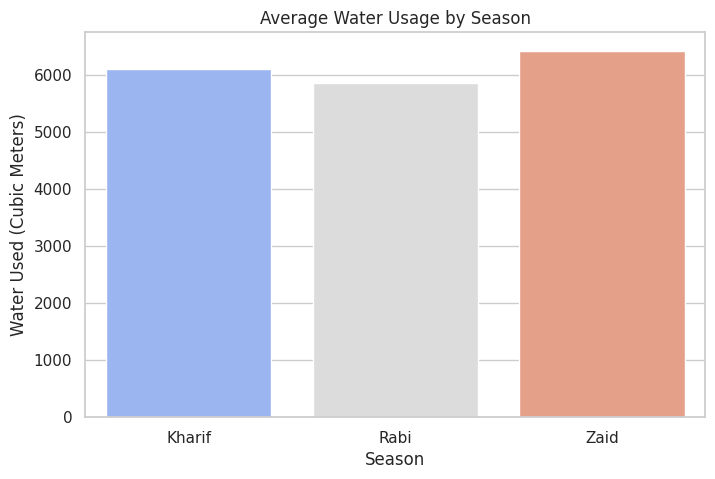

In [ ]:
# Graph 5: Resource Usage - Water Used by Season
plt.figure(figsize=(8, 5))
sns.barplot(x='Season', y='Water_Used_m3', data=df, palette='coolwarm', ci=None)
plt.title('Average Water Usage by Season')
plt.ylabel('Water Used (Cubic Meters)')
plt.show()

/tmp/ipykernel_1262/3179084067.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Season', y='Disease_Pest_Risk_pct', data=df, palette='Reds')


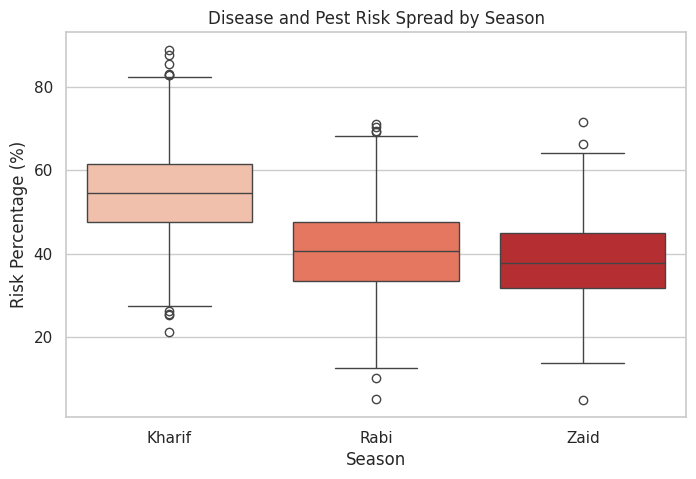

In [ ]:
# Graph 6: Disease & Pest Risk Percentage by Season
plt.figure(figsize=(8, 5))
sns.boxplot(x='Season', y='Disease_Pest_Risk_pct', data=df, palette='Reds')
plt.title('Disease and Pest Risk Spread by Season')
plt.ylabel('Risk Percentage (%)')
plt.show()

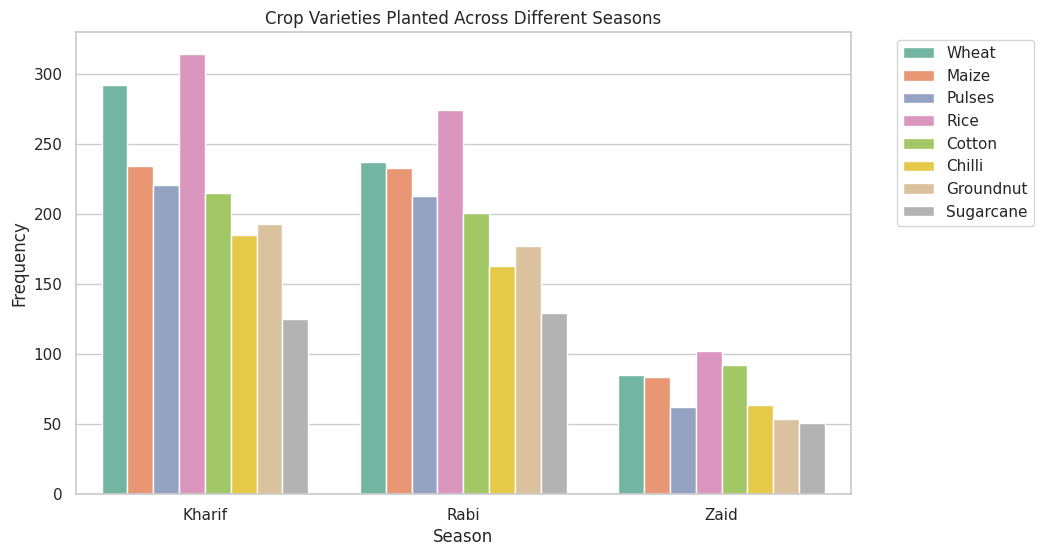

In [ ]:
# Graph 7: Popular Crops planted per Season
plt.figure(figsize=(10, 6))
sns.countplot(x='Season', hue='Crop', data=df, palette='Set2')
plt.title('Crop Varieties Planted Across Different Seasons')
plt.ylabel('Frequency')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### 7. Deep Dive & Multivariate Analysis
Exploring relationships between environmental conditions, resource usage, and economic outcomes to uncover hidden patterns.

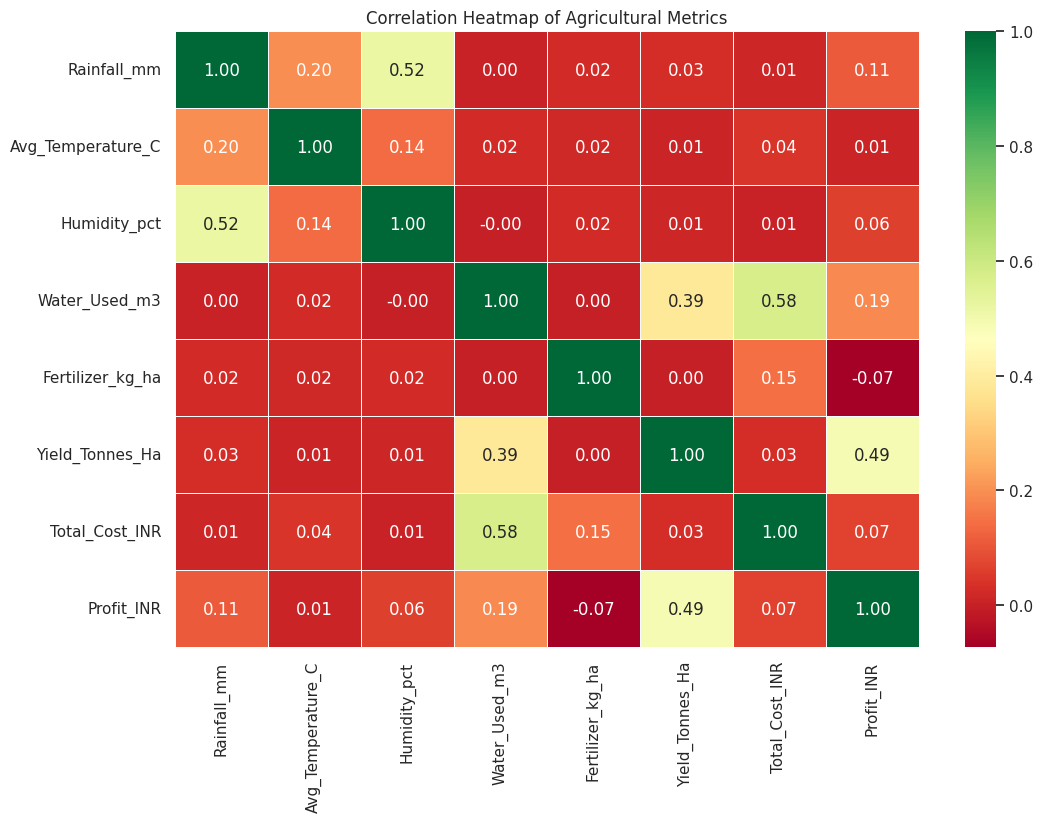

In [ ]:
# Graph 8: Correlation Heatmap of Key Variables
# This helps us see which factors (like rainfall or water usage) strongly affect yield and profit.

plt.figure(figsize=(12, 8))
# Select only numerical columns for correlation
numeric_cols = df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols[['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
                            'Water_Used_m3', 'Fertilizer_kg_ha', 'Yield_Tonnes_Ha',
                            'Total_Cost_INR', 'Profit_INR']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Agricultural Metrics')
plt.show()

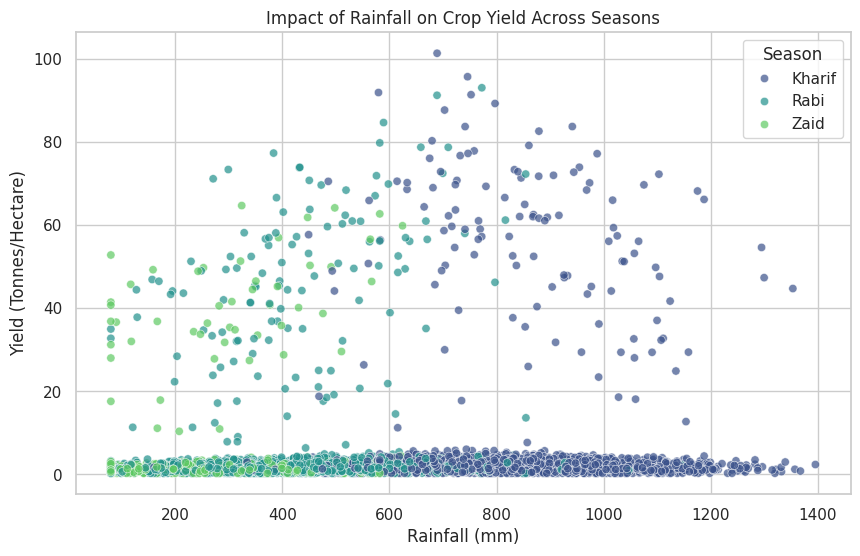

In [ ]:
# Graph 9: Scatter Plot of Rainfall vs. Yield (Colored by Season)
# Investigating the relationship between natural rainfall and final crop yield.

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', data=df, palette='viridis', alpha=0.7)
plt.title('Impact of Rainfall on Crop Yield Across Seasons')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Hectare)')
plt.legend(title='Season')
plt.show()

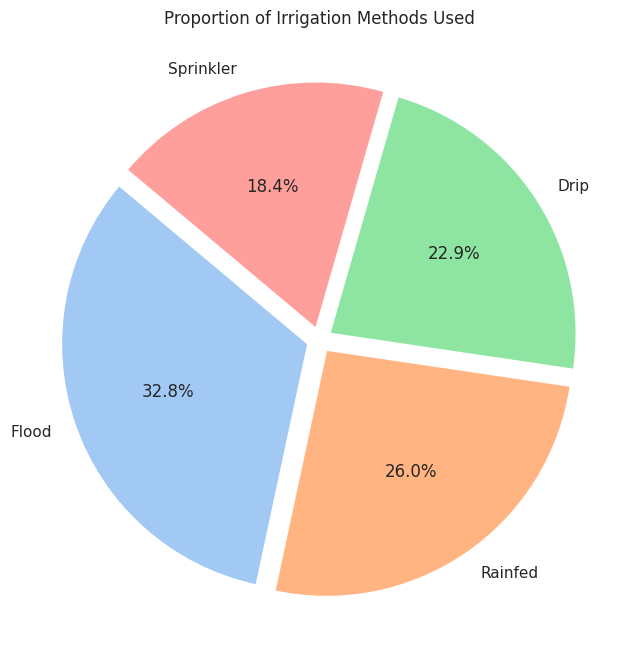

In [ ]:
# Graph 10: Distribution of Irrigation Methods
# Understanding how farmers are watering their crops.

plt.figure(figsize=(8, 8))
irrigation_counts = df['Irrigation_Method'].value_counts()
plt.pie(irrigation_counts, labels=irrigation_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('pastel'), startangle=140, explode=[0.05]*len(irrigation_counts))
plt.title('Proportion of Irrigation Methods Used')
plt.show()

/tmp/ipykernel_1262/4172723125.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Irrigation_Method', y='Water_Used_m3', data=df, palette='Set3')


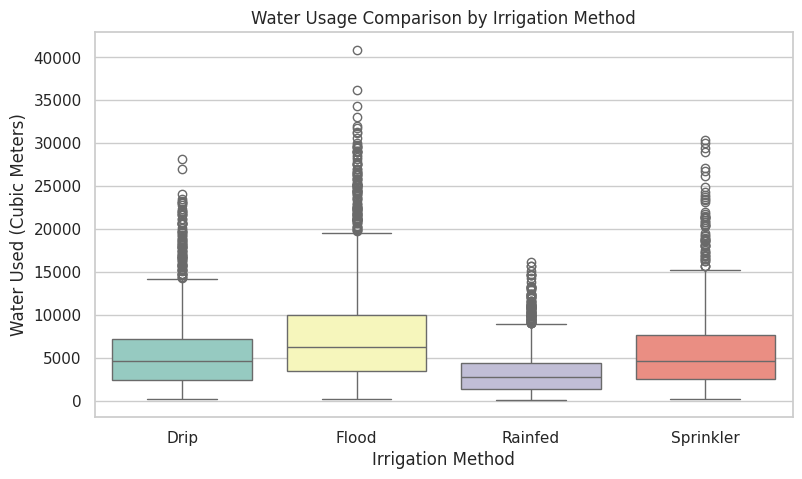

In [ ]:
# Graph 11: Water Usage by Irrigation Method
# Which irrigation method consumes the most water?

plt.figure(figsize=(9, 5))
sns.boxplot(x='Irrigation_Method', y='Water_Used_m3', data=df, palette='Set3')
plt.title('Water Usage Comparison by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Water Used (Cubic Meters)')
plt.show()

/tmp/ipykernel_1262/1017538359.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Profit_INR', y='Crop', data=crop_profit, palette='mako')


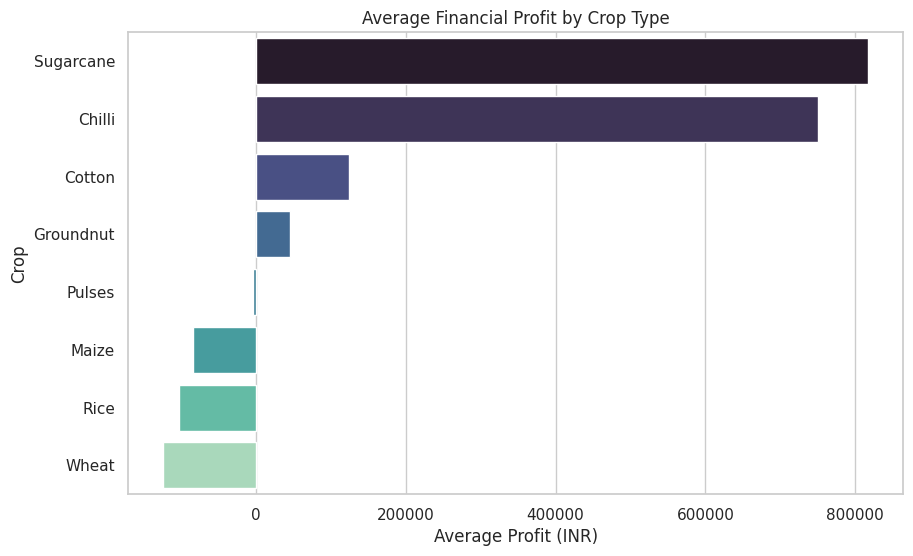

In [ ]:
# Graph 12: Average Profit by Crop Type
# Identifying the most financially viable crops.

plt.figure(figsize=(10, 6))
crop_profit = df.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False).reset_index()
sns.barplot(x='Profit_INR', y='Crop', data=crop_profit, palette='mako')
plt.title('Average Financial Profit by Crop Type')
plt.xlabel('Average Profit (INR)')
plt.ylabel('Crop')
plt.show()

/tmp/ipykernel_1262/879865108.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Season', y='Yield_Tonnes_Ha', data=df, palette='muted', inner='quartile')


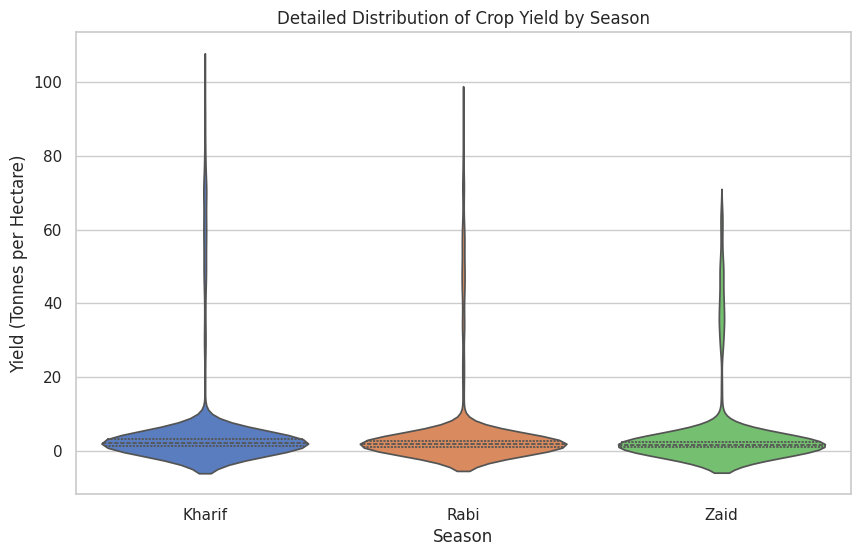

In [ ]:
# Graph 13: Distribution of Crop Yield Across Seasons (Violin Plot)
# This shows both the range of the yield and where the majority of farms fall (the thicker parts).

plt.figure(figsize=(10, 6))
sns.violinplot(x='Season', y='Yield_Tonnes_Ha', data=df, palette='muted', inner='quartile')
plt.title('Detailed Distribution of Crop Yield by Season')
plt.ylabel('Yield (Tonnes per Hectare)')
plt.show()

<Figure size 1400x700 with 0 Axes>

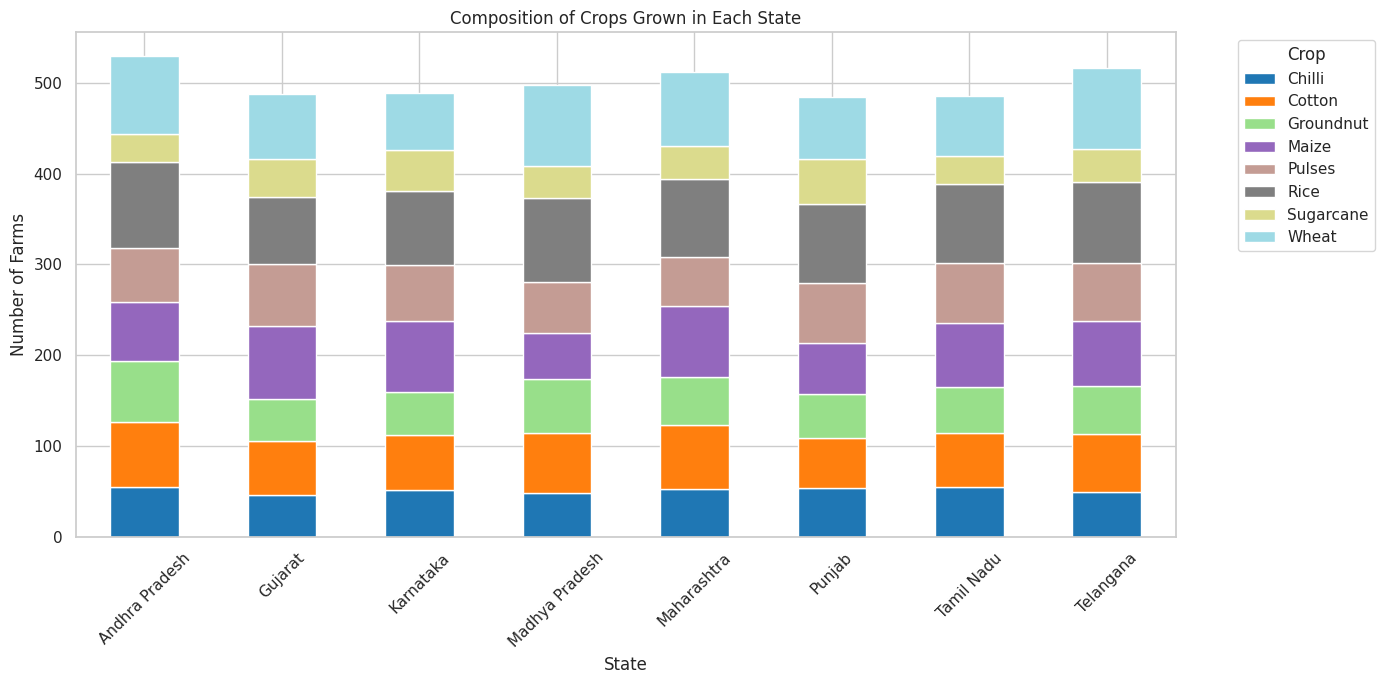

In [ ]:
# Graph 14: State-wise Crop Distribution (Stacked Bar Chart)
# This composition chart shows which states are producing which crops.

plt.figure(figsize=(14, 7))
# Create a crosstab of State and Crop, then plot it as a stacked bar
state_crop_matrix = pd.crosstab(df['State'], df['Crop'])
state_crop_matrix.plot(kind='bar', stacked=True, colormap='tab20', figsize=(14, 7))

plt.title('Composition of Crops Grown in Each State')
plt.xlabel('State')
plt.ylabel('Number of Farms')
plt.legend(title='Crop', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 8. Key Insights & Findings

Based on the descriptive, multivariate, and composition analytics performed on the agricultural dataset, the following meaningful patterns were identified:

1. **Seasonal Profitability & Volatility:** The **Kharif** season is the most profitable on average, heavily supported by high natural rainfall. However, the yield distribution (Violin Plot) shows a wide spread, indicating high volatility and inconsistency. It also carries the highest risk of disease and pests.
2. **Resource Strain in Zaid:** The **Zaid** (summer) season shows a concerning pattern. It requires the highest amount of artificial irrigation and has the highest total costs, yet it results in the lowest average yield and often negative profit margins.
3. **Regional Crop Specialization:** The composition analysis reveals strong state-wise crop dominance. Agricultural performance is not just tied to the season, but deeply linked to geographical crop selection and local farming practices.
4. **Irrigation Inefficiencies:** Flood irrigation is widely used but consumes significantly more water compared to Drip or Sprinkler methods, without always translating to proportionally higher profits.
5. **Predictability of Rabi:** The **Rabi** season represents a highly stable middle-ground. The distribution graphs show tighter, more predictable crop yields with moderate resource costs and lower pest risks.

### 9. Strategic Recommendations

To support better seasonal agricultural planning, the following data-driven recommendations are proposed:

* **Optimize Summer (Zaid) Planning:** Farmers should be strongly discouraged from planting high-water-consuming crops during the Zaid season. Subsidies should be redirected toward drought-resistant crops to prevent seasonal financial losses.
* **Modernize Irrigation:** There is a critical need to transition farmers from Flood irrigation to Drip or Sprinkler systems. This will drastically reduce water usage and lower total costs, which is especially critical during the dry Rabi and Zaid seasons.
* **Proactive Pest Management:** Since the Kharif season is highly profitable but highly prone to pests, early warning systems and subsidized pest control measures should be deployed right at the start of the monsoon.
* **Hyper-Local State Policies:** State agricultural boards should tailor their resource allocation (like fertilizer distribution) based on the specific crop composition dominating their region, rather than applying a universal seasonal strategy.

### 10. Conclusion

This project successfully investigated how agricultural performance changes across seasons and identified meaningful patterns and relationships within the data. By moving from basic univariate analysis to complex multivariate and distribution visualizations, it is evident that agriculture is not a uniform activity; strategies must be hyper-tailored to the season and region.

While the Kharif season thrives on natural resources, it requires intensive risk management. Conversely, the Zaid season demands strict resource optimization to remain economically viable. By leveraging these data-driven insights, stakeholders can make informed decisions to improve crop yields, conserve critical water resources, and maximize overall farmer profitability across the year.

**End of Analysis.**